## CELL 1: Import & Configuration

Import all required libraries for data processing and visualization.

In [1]:
# ============================================================================
# CELL 1: Import & Configuration
# ============================================================================
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import matplotlib.patches as mpatches
sys.path.append('../../src')
import accrediff as ad

## CELL 2: Global Configuration

Set up Nature-style plotting parameters and define color scheme for planetary compositions.

In [2]:
# ============================================================================
# CELL 2: Global Configuration
# ============================================================================

# ──────────────────────────────────────────────────────
# Nature style plotting parameters
# ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",        # Serif font for publication
    "font.size": 12,               # Main text font size
    "axes.linewidth": 1,           # Axes line width
    "axes.labelsize": 14,          # Axes label size
    "xtick.labelsize": 12,         # x-axis tick label size
    "ytick.labelsize": 12,         # y-axis tick label size
    "xtick.direction": "in",       # Tick marks pointing inward
    "ytick.direction": "in",
    "xtick.top": False,            # Remove top ticks
    "ytick.right": False,          # Remove right ticks
    "figure.dpi": 300              # High resolution for export
})

# ──────────────────────────────────────────────────────
# Color configuration for planetary bodies
# ──────────────────────────────────────────────────────
Colors = {
    'Earth': "#1f77b4",
    'Mars': "#d62728",
    'IW15': "green",
    'IW35': "purple",
}

## CELL 3: Notebook Title & Overview

**Bulk Composition Comparison with Earth**

Compare simulated planetary compositions with Earth's bulk composition. 
All values are normalized to MgO and Earth's reference composition.

### Core Steps
1. Load final planetary compositions from core formation model
2. Normalize all compositions by MgO content
3. Compare normalized values to Earth's reference composition
4. Visualize multi-element comparison across planets
5. Export processed results for further analysis

In [4]:
# ============================================================================
# CELL 3: Data Loading - Core Formation Composition Data
# ============================================================================

Model = 'note_02'  # ⭐ Adjustable parameter
data_name = Model+'_core_formation.xlsx'
base_path = '../Differentiation/Tables/'
#save_file = f'./Tables/{Model}.csv'

# ── File path construction ───────────────────────────

input_path = os.path.join(base_path, data_name)

# ── File existence check ─────────────────────────────
if not os.path.exists(input_path):
    raise FileNotFoundError(f"Input file not found: {input_path}")

# ── Data loading: all sheets ─────────────────────────
df_dict = pd.read_excel(input_path, sheet_name=None)

# ── Load confirmation ────────────────────────────────
print(f"✓ Loaded: {input_path}")
print(f"  Total sheets: {len(df_dict)}")
print(f"  Sheet names : {list(df_dict.keys())}")
print()

# ── Structure verification ──────────────────────────
sample_key = list(df_dict.keys())[0]
sample_df = df_dict[sample_key]

print(f"Sample dataset structure ({sample_key}):")
print(f"  Rows    : {len(sample_df)}")
print(f"  Columns : {list(sample_df.columns)[:10]}")
print()

✓ Loaded: ../Differentiation/Tables/note_02_core_formation.xlsx
  Total sheets: 3
  Sheet names : ['planets_1', 'planets_2', 'planets_3']

Sample dataset structure (planets_1):
  Rows    : 142
  Columns : ['Time', 'target_id', 'm_e', 'MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe']



## CELL 4: Data Inspection - Preview Sample Sheet

Display a sample sheet to understand the data structure and contents.

In [5]:
# ============================================================================
# CELL 4: Data Inspection - Preview Sample Sheet
# ============================================================================

# Display first sheet for inspection
sample_sheet = list(df_dict.keys())[0]
print(f"Displaying sample sheet: {sample_sheet}")
print()
df_dict[sample_sheet]

Displaying sample sheet: planets_1



,Time,target_id,m_e,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O
0,4.930942,6604,0.002504,0.350476,0.012646,0.018756,0.170452,0.000214,0.372605,0.062514,0.012329,0.000009,0.004203
1,4.935332,6243,0.014268,0.345569,0.015157,0.022087,0.024292,0.000015,0.322750,0.252498,0.015248,0.002383,0.001435
2,4.937856,4189,0.309152,0.341916,0.015269,0.022164,0.028875,0.000402,0.298470,0.255840,0.015384,0.021679,0.005618
3,4.964972,6439,0.001991,0.350476,0.012646,0.018756,0.170343,0.000202,0.372605,0.062622,0.012340,0.000009,0.004323
4,5.019652,4189,0.318787,0.341706,0.015213,0.022083,0.029019,0.000399,0.299802,0.255249,0.015363,0.021165,0.005541
...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,60.896827,6832,0.004275,0.347747,0.012813,0.018937,0.197105,0.000512,0.362804,0.047382,0.012694,0.000006,0.004986
138,61.048169,6832,0.005746,0.348445,0.012771,0.018891,0.190280,0.000437,0.365313,0.051257,0.012599,0.000007,0.004786
139,62.490856,4189,0.832303,0.341866,0.014804,0.021528,0.050986,0.002052,0.300096,0.227291,0.013343,0.028032,0.016778
140,63.905160,4189,0.838049,0.341911,0.014790,0.021510,0.051623,0.002077,0.300517,0.226403,0.013303,0.027866,0.017031


## CELL 5: Data Processing - Extract Final Planetary Compositions

Extract the final row (last timestep) from each planetary evolution record.
This represents the composition at the end of the simulation (100 Myr).

In [6]:
# ============================================================================
# CELL 5: Data Processing - Extract Final Planetary Compositions
# ============================================================================

# ── Initialize storage structure ─────────────────────
df_planets = pd.DataFrame()

print(f"✓ Processing final planetary compositions:")
print()

# ── Main loop: extract last row from each sheet ──────
for key in df_dict.keys():
    df = df_dict[key]
    
    if not df.empty:
        # Extract the last row (final state)
        last_row = df.iloc[[-1]].copy()
        
        # ── Result storage ───────────────────────────
        if df_planets.empty:
            df_planets = last_row
        else:
            df_planets = pd.concat([df_planets, last_row], ignore_index=True)
        
        # ── Progress report ──────────────────────────
        n_steps = len(df)
        print(f"  {key:20s}: {n_steps:5d} steps | Final composition extracted")

print()
print(f"✓ Total planets extracted: {len(df_planets)}")
print(f"  Shape: {df_planets.shape}")
print()

✓ Processing final planetary compositions:

  planets_1           :   142 steps | Final composition extracted
  planets_2           :    96 steps | Final composition extracted
  planets_3           :    26 steps | Final composition extracted

✓ Total planets extracted: 3
  Shape: (3, 13)



## CELL 6: Data Processing - Normalize by MgO Content

Divide all major element concentrations by MgO to obtain element/MgO ratios.
This normalization helps isolate compositional variations independent of bulk iron content.

In [7]:
# ============================================================================
# CELL 6: Data Processing - Normalize by MgO Content
# ============================================================================

# ── Define major elements ────────────────────────────
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items = ['Fe', 'Ni', 'Si', 'O']
major_items = mantle_items + core_items

# ── Normalize by MgO ─────────────────────────────────
df_planets_Mg = df_planets.copy()
denom = df_planets['MgO'].replace(0, np.nan)  # Protect against division by zero

df_planets_Mg[major_items] = df_planets_Mg[major_items].div(denom, axis=0)
df_planets_Mg = df_planets_Mg.fillna(np.inf)  # Fill NaN with infinity

# ── Verification ────────────────────────────────────
print(f"✓ Normalized by MgO content")
print(f"  Elements normalized: {major_items}")
print(f"  Output shape: {df_planets_Mg.shape}")
print()

✓ Normalized by MgO content
  Elements normalized: ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']
  Output shape: (3, 13)



## CELL 7: Data Processing - Normalize to Earth Composition

Compare normalized planetary compositions to Earth's reference values.
Ratio = (Planet element/MgO) / (Earth element/MgO)
A ratio of 1.0 indicates identical composition to Earth.

In [8]:
# ============================================================================
# CELL 7: Data Processing - Normalize to Earth Composition
# ============================================================================

# ── Load Earth reference composition ─────────────────
Earth_bulk_mg = ad.constants.Earth_bulk_mg
df_Earth_bulk_mg = pd.DataFrame([Earth_bulk_mg], columns=Earth_bulk_mg.keys())

# ── Load Mars reference composition ──────────────────
Mars_bulk_mg = ad.constants.Mars_bulk_mg
df_Mars_bulk_mg = pd.DataFrame([Mars_bulk_mg], columns=Mars_bulk_mg.keys())

# ── Identify common elements ─────────────────────────
common = df_planets_Mg.columns.intersection(df_Earth_bulk_mg.columns).tolist()

# ── Normalize to Earth composition ───────────────────
base = df_Earth_bulk_mg.reindex(columns=common[1:]).iloc[0]
df_planets_Earth = df_planets_Mg.reindex(columns=common[1:]).div(base, axis=1)
df_Mars_bulk_earth = df_Mars_bulk_mg.reindex(columns=common[1:]).div(base, axis=1)

# ── Concatenate planets + Mars ───────────────────────
df_planets_Earth = pd.concat([df_planets_Earth, df_Mars_bulk_earth], ignore_index=True)

# ── Verification ────────────────────────────────────
print(f"✓ Normalized to Earth bulk composition")
print(f"  Common elements: {common[1:]}")
print(f"  Comparison data shape: {df_planets_Earth.shape}")
print(f"  (Rows: {len(df_planets)} planets + 1 Mars)")
print()

✓ Normalized to Earth bulk composition
  Common elements: ['Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']
  Comparison data shape: (4, 9)
  (Rows: 3 planets + 1 Mars)



## CELL 8: Visualization - Multi-Element Composition Comparison

Create a scatter plot comparing normalized elemental abundances.
Each planet is shown as a square with size proportional to its mass.
Mars is shown as a star marker.
The gray band (0.9-1.1) indicates Earth's reference range.

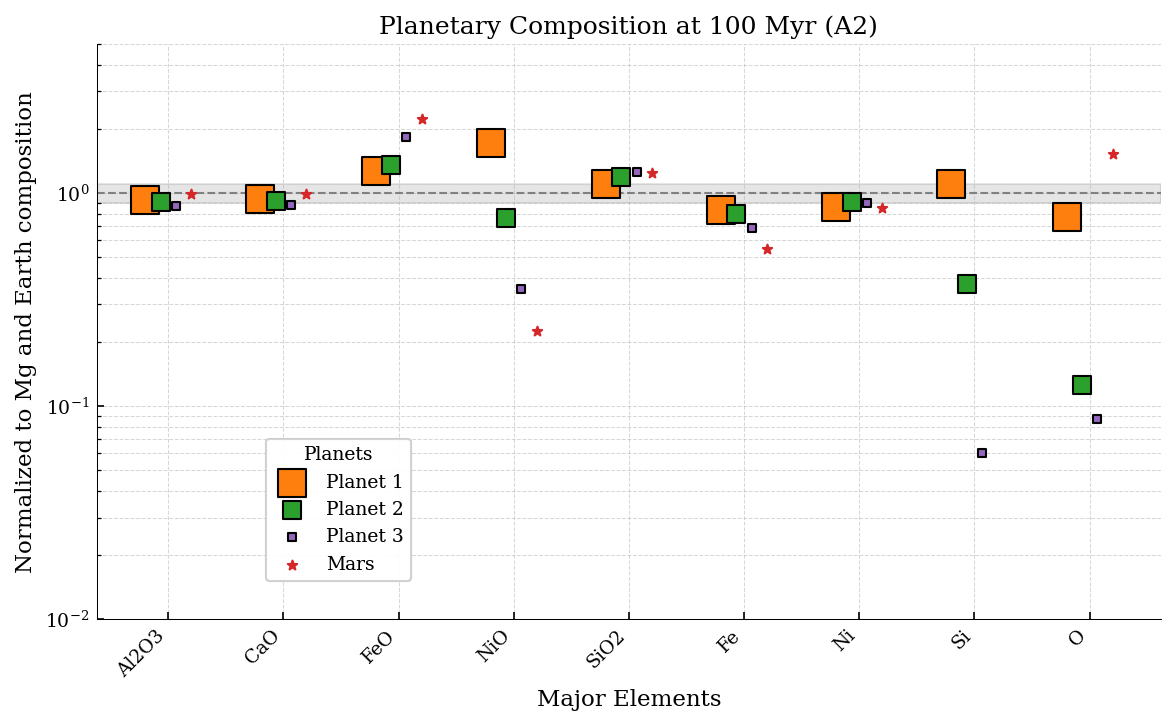

✓ Visualization displayed



In [9]:
# ============================================================================
# CELL 8: Visualization - Multi-Element Composition Comparison
# ============================================================================

# ── Data preparation ─────────────────────────────────
embryos_id = [f'Planet {i+1}' for i in range(len(df_planets))]
cmap = plt.get_cmap('tab10')
n_embryos = len(df_planets)

# Skip tab10 colors 0 (blue) and 3 (dark blue)
color_indices = [i for i in range(10) if i not in (0, 3)]
embryo_colors = [cmap(color_indices[i % len(color_indices)]) for i in range(n_embryos)]

# ── Figure initialization ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

# ── Plotting data preparation ────────────────────────
x_idx = np.arange(len(common) - 1)
offsets = np.linspace(-0.2, 0.2, len(df_planets_Earth))

# ── Plot each planet ─────────────────────────────────
for i in range(len(df_planets_Earth) - 1):
    x = x_idx + offsets[i]
    y = df_planets_Earth.iloc[i].to_numpy(dtype=float)
    
    ax.scatter(x, y, marker='s', s=200 * df_planets['m_e'].iloc[i],
               label=f'{embryos_id[i]}', color=embryo_colors[i], 
               edgecolor="k", alpha=1, zorder=4)

# ── Plot Mars ────────────────────────────────────────
y_mars = df_planets_Earth.iloc[-1].to_numpy(dtype=float)
ax.scatter(x_idx + offsets[-1], y_mars,
           marker='*', s=200 * ad.constants.Mars_ME, label='Mars', 
           color=Colors['Mars'], alpha=1, zorder=4)

# ── Style customization ──────────────────────────────
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Gray band: y ∈ [0.9, 1.1] (Earth reference range)
ax.axhspan(0.9, 1.1, color='gray', alpha=0.2, zorder=0, label='Earth range')

# ── Axes configuration ───────────────────────────────
ax.set_yscale('log')
ax.set_ylim(0.01, 5)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, zorder=2)

ax.set_xticks(x_idx)
ax.set_xticklabels(common[1:], rotation=45, ha='right', fontsize=10)
ax.set_xlabel("Major Elements", fontsize=11)
ax.set_ylabel("Normalized to Mg and Earth composition", fontsize=11)
ax.set_title('Planetary Composition at 100 Myr (A2)', fontsize=12, pad=5)

ax.tick_params(labelsize=9)
ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.5, zorder=1)

# ── Legend configuration ─────────────────────────────
handles, labels = ax.get_legend_handles_labels()
keep = [("Planet" in l) or (l == "Mars") for l in labels]
first_handles = [h for h, k in zip(handles, keep) if k]
first_labels = [l for l, k in zip(labels, keep) if k]

first_legend = ax.legend(first_handles, first_labels, title="Planets",
                         bbox_to_anchor=(0.15, 0.05), loc="lower left", 
                         fontsize=9, title_fontsize=9, frameon=True)
ax.add_artist(first_legend)

plt.tight_layout()
plt.show()

print(f"✓ Visualization displayed")
print()

## CELL 9: Export Results

Save the MgO-normalized composition data to CSV format for further analysis.

In [10]:
# ============================================================================
# CELL 9: Export Results
# ============================================================================

save_dir = './Tables'
os.makedirs(save_dir, exist_ok=True)
save_file = f'./Tables/{Model}.csv'
# ── Export data ──────────────────────────────────────
df_planets_Mg.to_csv(save_file, index=True)

# ── Export confirmation ──────────────────────────────
print(f"✅ Exported: {save_file}")
print(f"  Rows    : {len(df_planets_Mg)}")
print(f"  Columns : {len(df_planets_Mg.columns)}")
print()

# ── File verification ────────────────────────────────
file_size_kb = os.path.getsize(save_file) / 1024
print(f"  File size: {file_size_kb:.2f} KB")
print()

✅ Exported: ./Tables/note_02.csv
  Rows    : 3
  Columns : 13

  File size: 0.73 KB



## CELL 10: Data Verification & Inspection

Reload the exported CSV file and verify data integrity.
Display sample rows to confirm successful export.

In [11]:
# ============================================================================
# CELL 10: Data Verification & Inspection
# ============================================================================

# ── Reload exported data ─────────────────────────────
data = pd.read_csv(save_file, index_col=0)

# ── Verify data integrity ───────────────────────────
print(f"✓ Verification: Reloaded {save_file}")
print(f"  Rows    : {len(data)}")
print(f"  Columns : {len(data.columns)}")
print()

# ── Sample inspection ────────────────────────────────
print(f"Sample data (first 3 rows, first 5 columns):")
print(data.iloc[:3, :5])
print()

print(f"✅ Data integrity verified")
print()

✓ Verification: Reloaded ./Tables/note_02.csv
  Rows    : 3
  Columns : 13

Sample data (first 3 rows, first 5 columns):
        Time  target_id       m_e  MgO     Al2O3
0  96.532137       4189  0.841634  1.0  0.043239
1  57.253020       2768  0.353523  1.0  0.042258
2  53.386374       4755  0.081899  1.0  0.040538

✅ Data integrity verified

